# Import libraries

In [1]:
import os
import cv2
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from torchsummary import summary

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline


# Dataset path

In [2]:
# --- Data paths ---
DATA_DIR = r'C:\inten\FT_Methods_for_Fetal_Head_Segmentation-main\dataset'
x_train_dir = os.path.join(DATA_DIR, 'train', 'images')
y_train_dir = os.path.join(DATA_DIR, 'train', 'masks')
x_valid_dir = os.path.join(DATA_DIR, 'val', 'images')
y_valid_dir = os.path.join(DATA_DIR, 'val', 'masks')
x_test_dir  = os.path.join(DATA_DIR, 'test', 'images')
select_class_gray_values = [255]


In [3]:
def visualize(**images):
    n = len(images)
    plt.figure(figsize=(5*n, 5))
    for i, (name, image) in enumerate(images.items()):
        plt.subplot(1, n, i + 1)
        plt.title(name)
        plt.imshow(image.squeeze(), cmap='gray')
        plt.axis('off')
    plt.show()

In [4]:
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset
from glob import glob
import os

def fill_mask_border(mask):
    """Fill the white ellipse border in a binary mask to create a solid region."""
    mask = (mask * 255).astype(np.uint8) if mask.max() <= 1 else mask.copy()
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filled_mask = np.zeros_like(mask)
    cv2.drawContours(filled_mask, contours, -1, color=255, thickness=cv2.FILLED)
    return (filled_mask / 255).astype(np.float32)

class FetalHeadDataset(Dataset):
    def __init__(self, images_dir, masks_dir, class_gray_values, augmentation=None, preprocessing=None):
        self.image_paths = sorted(glob(os.path.join(images_dir, '*')))
        self.mask_paths  = sorted(glob(os.path.join(masks_dir, '*')))
        self.class_gray_values = class_gray_values
        self.augmentation = augmentation
        self.preprocessing = preprocessing

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, i):
        image = cv2.imread(self.image_paths[i], cv2.IMREAD_GRAYSCALE)
        mask  = cv2.imread(self.mask_paths[i],  cv2.IMREAD_GRAYSCALE)

        if image is None:
            raise FileNotFoundError(f"Image not found: {self.image_paths[i]}")
        if mask is None:
            raise FileNotFoundError(f"Mask not found: {self.mask_paths[i]}")

        # Normalize image
        image = image.astype('float32') / 255.0

        # Fill ellipse in mask
        mask = fill_mask_border(mask)

        # Optional: filter to specific classes if needed
        if self.class_gray_values:
            mask = np.isin(mask * 255, self.class_gray_values).astype('float32')  # Recheck gray value logic
        else:
            mask = mask.astype('float32')

        image = np.expand_dims(image, -1)
        mask  = np.expand_dims(mask, -1)

        if self.augmentation:
            augmented = self.augmentation(image=image, mask=mask)
            image, mask = augmented['image'], augmented['mask']

        if self.preprocessing:
            processed = self.preprocessing(image=image, mask=mask)
            image, mask = processed['image'], processed['mask']

        if isinstance(mask, torch.Tensor):
            if mask.ndim == 4 and mask.shape[-1] == 1:
                mask = mask.squeeze(-1)
            if mask.ndim == 2:
                mask = mask.unsqueeze(0)
            if mask.ndim == 3 and mask.shape[0] != 1 and mask.shape[-1] == 1:
                mask = mask.permute(2, 0, 1)
        elif isinstance(mask, np.ndarray):
            if mask.ndim == 4 and mask.shape[-1] == 1:
                mask = np.squeeze(mask, axis=-1)
            if mask.ndim == 2:
                mask = np.expand_dims(mask, 0)
            if mask.ndim == 3 and mask.shape[0] != 1 and mask.shape[-1] == 1:
                mask = np.transpose(mask, (2, 0, 1))
            mask = torch.from_numpy(mask).float()

        assert mask.shape == (1, 256, 256), f"Mask shape: {mask.shape}"

        if isinstance(image, torch.Tensor):
            if image.ndim == 4 and image.shape[-1] == 1:
                image = image.squeeze(-1)
            if image.ndim == 2:
                image = image.unsqueeze(0)
            if image.ndim == 3 and image.shape[0] != 1 and image.shape[-1] == 1:
                image = image.permute(2, 0, 1)
        elif isinstance(image, np.ndarray):
            if image.ndim == 4 and image.shape[-1] == 1:
                image = np.squeeze(image, axis=-1)
            if image.ndim == 2:
                image = np.expand_dims(image, 0)
            if image.ndim == 3 and image.shape[0] != 1 and image.shape[-1] == 1:
                image = np.transpose(image, (2, 0, 1))
            image = torch.from_numpy(image).float()

        assert image.shape == (1, 256, 256), f"Image shape: {image.shape}"

        return image, mask


In [5]:
def get_training_augmentation():
    return A.Compose([
        A.PadIfNeeded(256, 256),
        A.RandomCrop(256, 256),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.RandomBrightnessContrast(p=0.15),
        A.GaussNoise(var_limit=(10.0,50.0), p=0.1),
    ])

def get_validation_augmentation():
    return A.Compose([
        A.PadIfNeeded(256,256),
        A.CenterCrop(256,256)
    ])

def get_preprocessing():
    return A.Compose([
        A.Normalize(mean=(0.0,), std=(1.0,), max_pixel_value=1.0),
        ToTensorV2()
    ])

In [6]:
BATCH_SIZE = 8
NUM_WORKERS = 0

train_dataset = FetalHeadDataset(
    x_train_dir, y_train_dir,
    class_gray_values=select_class_gray_values,
    augmentation=get_training_augmentation(),
    preprocessing=get_preprocessing()
)
val_dataset = FetalHeadDataset(
    x_valid_dir, y_valid_dir,
    class_gray_values=select_class_gray_values,
    augmentation=get_validation_augmentation(),
    preprocessing=get_preprocessing()
)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=NUM_WORKERS)


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class AttentionUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()

        # Encoder
        self.enc1 = ConvBlock(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = ConvBlock(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = ConvBlock(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.enc4 = ConvBlock(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = ConvBlock(512, 1024)

        # Decoder + Attention + Up
        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.att4 = AttentionBlock(F_g=512, F_l=512, F_int=256)
        self.dec4 = ConvBlock(1024, 512)

        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.att3 = AttentionBlock(F_g=256, F_l=256, F_int=128)
        self.dec3 = ConvBlock(512, 256)

        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.att2 = AttentionBlock(F_g=128, F_l=128, F_int=64)
        self.dec2 = ConvBlock(256, 128)

        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.att1 = AttentionBlock(F_g=64, F_l=64, F_int=32)
        self.dec1 = ConvBlock(128, 64)

        # Final
        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))

        # Bottleneck
        b = self.bottleneck(self.pool4(e4))

        # Decoder with Attention
        d4 = self.upconv4(b)
        e4 = self.att4(g=d4, x=e4)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.upconv3(d4)
        e3 = self.att3(g=d3, x=e3)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.upconv2(d3)
        e2 = self.att2(g=d2, x=e2)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.upconv1(d2)
        e1 = self.att1(g=d1, x=e1)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.final_conv(d1)


In [17]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


model = AttentionUNet(in_channels=1, out_channels=1).to(DEVICE)


Using device: cuda


In [9]:
from segmentation_models_pytorch.losses import FocalLoss
import segmentation_models_pytorch as smp
import torch
import numpy as np
from tqdm import tqdm
import os
import matplotlib.pyplot as plt

class DiceBCELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
    
    def forward(self, inputs, targets):
        inputs = torch.sigmoid(inputs)  # Needed because you use logits
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        smooth = 1.
        intersection = (inputs * targets).sum()
        dice = (2.*intersection + smooth) / (inputs.sum() + targets.sum() + smooth)
        return 1 - dice + self.bce(inputs, targets)


# Optimizer and scheduler
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=4, factor=0.5, min_lr=1e-6)

# Helper metric functions
def safe_div(numerator, denominator):
    return (numerator + 1e-7) / (denominator + 1e-7) if denominator != 0 else 0.0


In [10]:
def iou_pytorch(outputs, labels, threshold=0.5):
    outputs = (outputs > threshold).float()
    labels = (labels > 0.5).float()
    intersection = (outputs * labels).sum()
    union = (outputs + labels).clamp(0, 1).sum()
    return safe_div(intersection, union)

def dice_pytorch(outputs, labels, threshold=0.5):
    outputs = (outputs > threshold).float()
    labels = (labels > 0.5).float()
    intersection = (outputs * labels).sum()
    total = outputs.sum() + labels.sum()
    return safe_div(2 * intersection, total)

def precision_pytorch(outputs, labels, threshold=0.5):
    outputs = (outputs > threshold).float()
    labels = (labels > 0.5).float()
    tp = (outputs * labels).sum()
    fp = (outputs * (1 - labels)).sum()
    return safe_div(tp, tp + fp)

def recall_pytorch(outputs, labels, threshold=0.5):
    outputs = (outputs > threshold).float()
    labels = (labels > 0.5).float()
    tp = (outputs * labels).sum()
    fn = ((1 - outputs) * labels).sum()
    return safe_div(tp, tp + fn)

def accuracy_pytorch(outputs, labels, threshold=0.5):
    outputs = (outputs > threshold).float()
    labels = (labels > 0.5).float()
    correct = (outputs == labels).float().sum()
    total = torch.numel(outputs)
    return safe_div(correct, total)

def f1_score_pytorch(outputs, labels, threshold=0.5):
    prec = precision_pytorch(outputs, labels, threshold)
    rec = recall_pytorch(outputs, labels, threshold)
    return safe_div(2 * prec * rec, prec + rec)

In [11]:
def train_epoch(loader, model, loss_fn, optimizer, device):
    model.train()
    metrics = {'loss': 0, 'iou': 0, 'dice': 0, 'precision': 0, 'recall': 0, 'accuracy': 0, 'f1': 0}
    for images, masks in tqdm(loader):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss_fn = DiceBCELoss()
        loss = loss_fn(logits, masks)
        loss.backward()
        optimizer.step()
        probs = torch.sigmoid(logits)

        metrics['loss'] += loss.item()
        metrics['iou'] += iou_pytorch(probs, masks)
        metrics['dice'] += dice_pytorch(probs, masks)
        metrics['precision'] += precision_pytorch(probs, masks)
        metrics['recall'] += recall_pytorch(probs, masks)
        metrics['accuracy'] += accuracy_pytorch(probs, masks)
        metrics['f1'] += f1_score_pytorch(probs, masks)

    n = len(loader)
    return {k: v / n for k, v in metrics.items()}

def eval_epoch(loader, model, loss_fn, device):
    model.eval()
    metrics = {'loss': 0, 'iou': 0, 'dice': 0, 'precision': 0, 'recall': 0, 'accuracy': 0, 'f1': 0}
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            logits = model(images)
            loss_fn = DiceBCELoss()
            loss = loss_fn(logits, masks)
            probs = torch.sigmoid(logits)

            metrics['loss'] += loss.item()
            metrics['iou'] += iou_pytorch(probs, masks)
            metrics['dice'] += dice_pytorch(probs, masks)
            metrics['precision'] += precision_pytorch(probs, masks)
            metrics['recall'] += recall_pytorch(probs, masks)
            metrics['accuracy'] += accuracy_pytorch(probs, masks)
            metrics['f1'] += f1_score_pytorch(probs, masks)

    n = len(loader)
    return {k: v / n for k, v in metrics.items()}

In [12]:
NUM_EPOCHS = 100
PATIENCE = 25  # stop if no improvement after 25 epochs
counter = 0

best_val_iou, best_epoch = 0, 0
best_model_path = os.path.join(DATA_DIR, 'best_model_attention_unet.pth')

log = {
    'train_loss': [], 'val_loss': [],
    'train_iou': [], 'val_iou': [],
    'train_dice': [], 'val_dice': [],
    'train_precision': [], 'val_precision': [],
    'train_accuracy': [], 'val_accuracy': [],
    'train_recall': [], 'val_recall': [],
    'train_f1': [], 'val_f1': []
}

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    # Training
    train_metrics = train_epoch(train_loader, model, DiceBCELoss, optimizer, DEVICE)

    # Validation
    val_metrics = eval_epoch(val_loader, model, DiceBCELoss, DEVICE)

    # Scheduler step
    lr_scheduler.step(val_metrics['loss'])

    # Logging
    print(f"Train Loss: {train_metrics['loss']:.4f} | Val Loss: {val_metrics['loss']:.4f}")
    print(f"Train IoU: {train_metrics['iou']:.4f} | Val IoU: {val_metrics['iou']:.4f}")
    print(f"Train Dice: {train_metrics['dice']:.4f} | Val Dice: {val_metrics['dice']:.4f}")
    print(f"Train Precision: {train_metrics['precision']:.4f} | Val Precision: {val_metrics['precision']:.4f}")
    print(f"Train Accuracy: {train_metrics['accuracy']:.4f} | Val Accuracy: {val_metrics['accuracy']:.4f}")
    print(f"Train Recall: {train_metrics['recall']:.4f} | Val Recall: {val_metrics['recall']:.4f}")
    print(f"Train F1: {train_metrics['f1']:.4f} | Val F1: {val_metrics['f1']:.4f}")

    for key in log.keys():
        metric_name = key.split('_', 1)[1]
        if key.startswith('train_'):
            log[key].append(train_metrics[metric_name])
        else:
            log[key].append(val_metrics[metric_name])

    # Early Stopping & Save Best Model
    if val_metrics['iou'] > best_val_iou:
        best_val_iou, best_epoch = val_metrics['iou'], epoch
        torch.save(model.state_dict(), best_model_path)
        print(f"✅ Best checkpoint saved at epoch {epoch+1} with Val IoU: {best_val_iou:.4f}")
        counter = 0  # reset counter if improved
    else:
        counter += 1
        print(f"⏳ No improvement for {counter} epoch(s).")

    if counter >= PATIENCE:
        print(f"\n🛑 Early stopping triggered at epoch {epoch+1}")
        break

# Final summary
print(f"\n🏁 Best Val IoU: {best_val_iou:.4f} at epoch {best_epoch+1}")



Epoch 1/100


100%|██████████| 100/100 [00:52<00:00,  1.92it/s]


Train Loss: 1.0594 | Val Loss: 0.5505
Train IoU: 0.5413 | Val IoU: 0.8707
Train Dice: 0.6980 | Val Dice: 0.9160
Train Precision: 0.5981 | Val Precision: 0.9107
Train Accuracy: 0.6036 | Val Accuracy: 0.8764
Train Recall: 0.8517 | Val Recall: 0.9556
Train F1: 0.6980 | Val F1: 0.9160
✅ Best checkpoint saved at epoch 1 with Val IoU: 0.8707

Epoch 2/100


100%|██████████| 100/100 [00:52<00:00,  1.91it/s]


Train Loss: 1.0121 | Val Loss: 0.6257
Train IoU: 0.5502 | Val IoU: 0.8202
Train Dice: 0.7051 | Val Dice: 0.8813
Train Precision: 0.6223 | Val Precision: 0.9120
Train Accuracy: 0.6226 | Val Accuracy: 0.8282
Train Recall: 0.8335 | Val Recall: 0.8971
Train F1: 0.7051 | Val F1: 0.8813
⏳ No improvement for 1 epoch(s).

Epoch 3/100


...

Train Loss: 0.8009 | Val Loss: 0.5610
Train IoU: 0.6778 | Val IoU: 0.8004
Train Dice: 0.8046 | Val Dice: 0.8682
Train Precision: 0.7801 | Val Precision: 0.9498
Train Accuracy: 0.7780 | Val Accuracy: 0.8231
Train Recall: 0.8453 | Val Recall: 0.8392
Train F1: 0.8046 | Val F1: 0.8682
⏳ No improvement for 23 epoch(s).

Epoch 25/100


100%|██████████| 100/100 [01:05<00:00,  1.52it/s]


Train Loss: 0.7890 | Val Loss: 0.5821
Train IoU: 0.6887 | Val IoU: 0.7831
Train Dice: 0.8126 | Val Dice: 0.8548
Train Precision: 0.7891 | Val Precision: 0.9526
Train Accuracy: 0.7896 | Val Accuracy: 0.8104
Train Recall: 0.8528 | Val Recall: 0.8143
Train F1: 0.8126 | Val F1: 0.8548
⏳ No improvement for 24 epoch(s).

Epoch 26/100


100%|██████████| 100/100 [00:58<00:00,  1.71it/s]


Train Loss: 0.7869 | Val Loss: 0.5243
Train IoU: 0.6858 | Val IoU: 0.8407
Train Dice: 0.8108 | Val Dice: 0.8954
Train Precision: 0.7896 | Val Precision: 0.9506
Train Accuracy: 0.7821 | Val Accuracy: 0.8621
Train Recall: 0.8456 | Val Recall: 0.8779
Train F1: 0.8108 | Val F1: 0.8954
⏳ No improvement for 25 epoch(s).

🛑 Early stopping triggered at epoch 26

🏁 Best Val IoU: 0.8707 at epoch 1


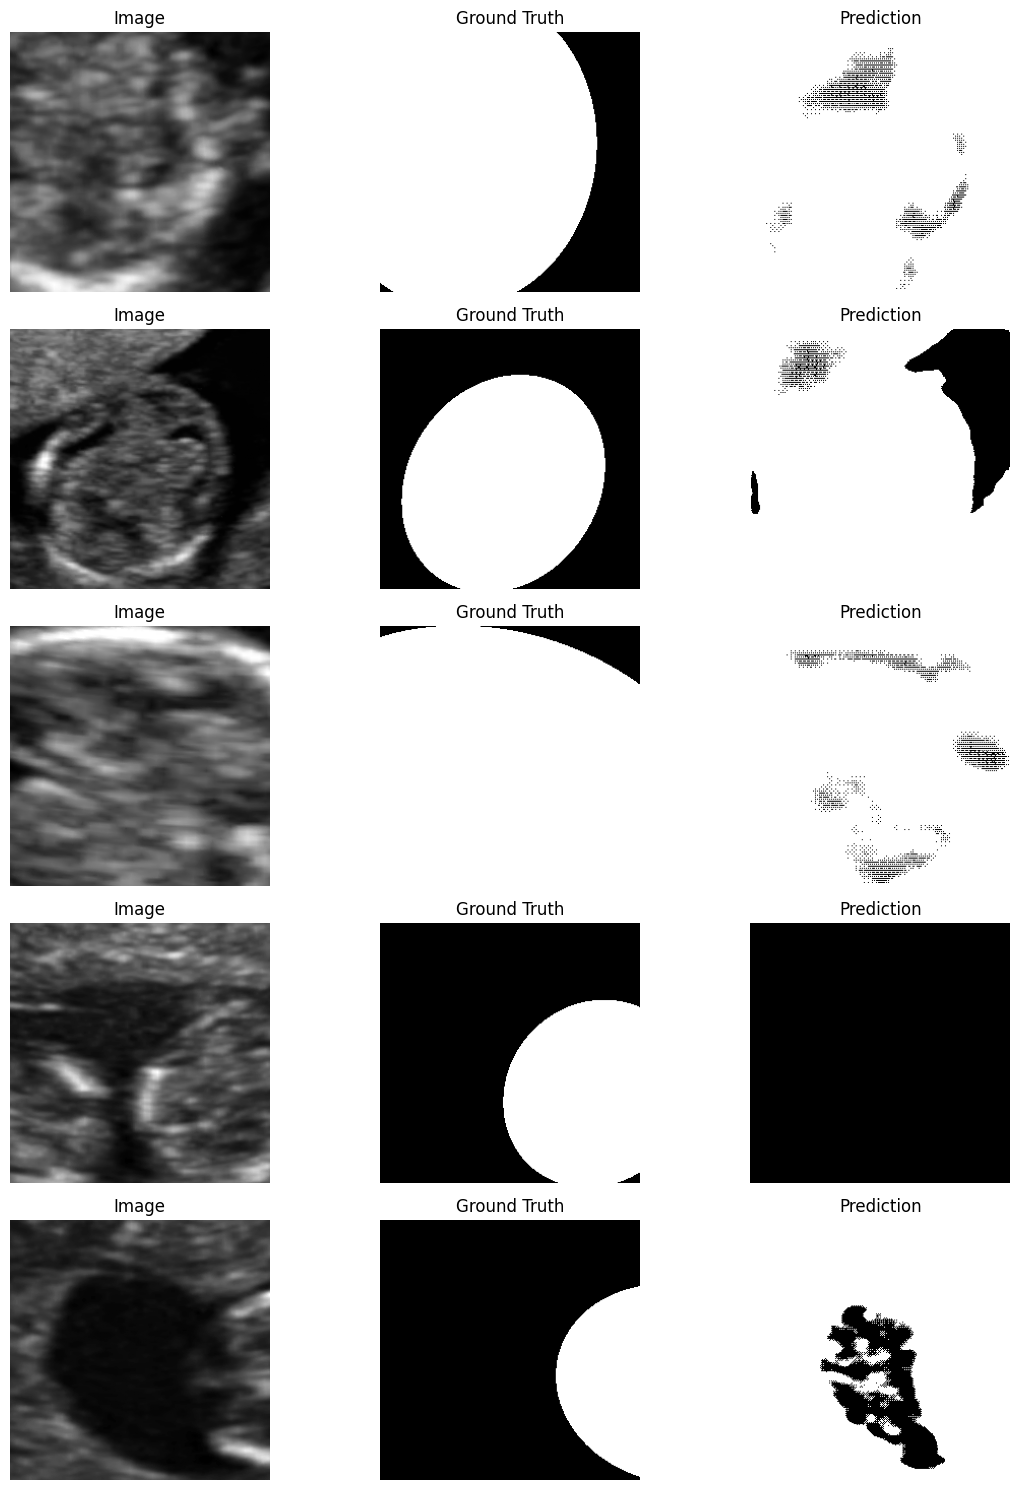

In [13]:
import matplotlib.pyplot as plt

# Load best model weights
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

# Show predictions on a few validation samples
n_samples = 5  # Number of images to visualize
fig, axs = plt.subplots(n_samples, 3, figsize=(12, n_samples * 3))

with torch.no_grad():
    for i in range(n_samples):
        # Get image and mask from validation dataset
        img, mask = val_dataset[i]
        img_input = img.unsqueeze(0).to(DEVICE)

        # Predict
        pred = torch.sigmoid(model(img_input))
        pred_mask = (pred[0, 0].cpu().numpy() > 0.5)

        # Plot
        axs[i, 0].imshow(img[0].cpu(), cmap='gray')
        axs[i, 0].set_title("Image")
        axs[i, 0].axis('off')

        axs[i, 1].imshow(mask[0].cpu(), cmap='gray')
        axs[i, 1].set_title("Ground Truth")
        axs[i, 1].axis('off')

        axs[i, 2].imshow(pred_mask, cmap='gray')
        axs[i, 2].set_title("Prediction")
        axs[i, 2].axis('off')

plt.tight_layout()
plt.show()


Using device: cuda
[✅] Results saved to: C:\inten\FT_Methods_for_Fetal_Head_Segmentation-main\test\predicted_masks_attention_unet
[📄] CSV saved as: C:\inten\FT_Methods_for_Fetal_Head_Segmentation-main\test\predicted_masks_attention_unet\head_circumference_results.csv

[🖼️] Displaying Results...


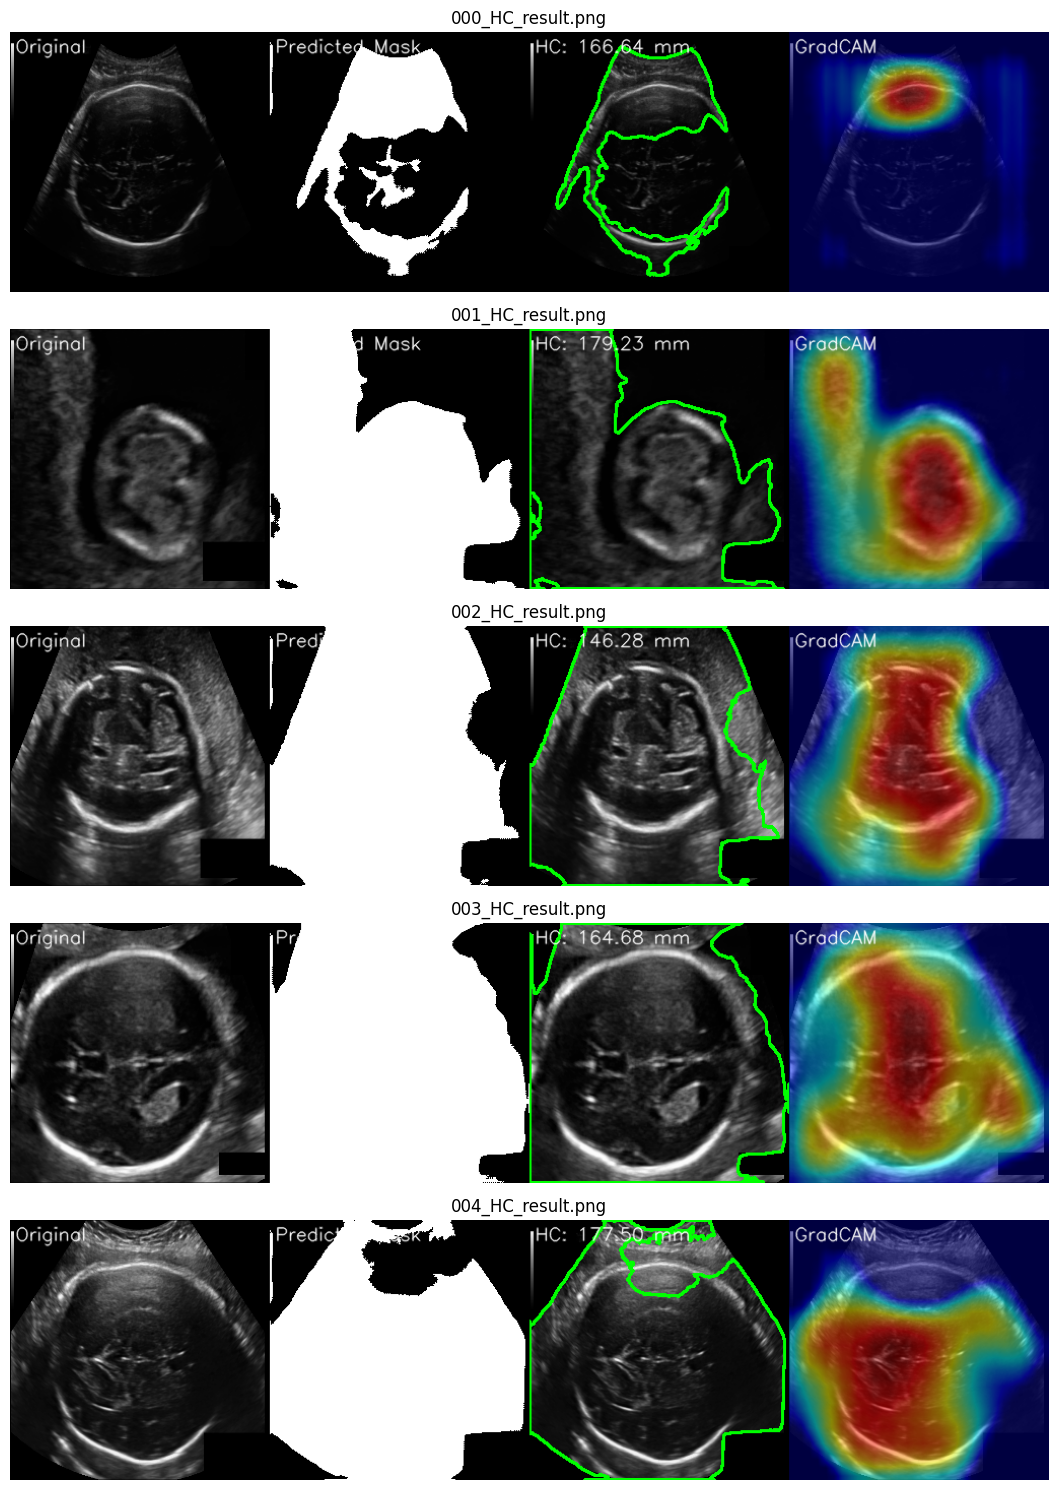

In [20]:
import os
import glob
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils.data import DataLoader, Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2

# --- Dataset Class ---
class TestDataset(Dataset):
    def __init__(self, image_paths):
        self.image_paths = image_paths
        self.transform = A.Compose([
            A.Resize(256, 256),
            A.Normalize(mean=(0.0,), std=(1.0,), max_pixel_value=255.0),
            ToTensorV2()
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = cv2.imread(self.image_paths[idx], cv2.IMREAD_GRAYSCALE)
        augmented = self.transform(image=image)
        return augmented['image'], self.image_paths[idx]

# --- Clean Prediction ---
def clean_prediction_mask(mask_tensor, area_thresh=100):
    mask_np = mask_tensor.squeeze().cpu().numpy().astype(np.uint8)
    contours, _ = cv2.findContours(mask_np, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask_clean = np.zeros_like(mask_np)
    for cnt in contours:
        if cv2.contourArea(cnt) > area_thresh:
            cv2.drawContours(mask_clean, [cnt], -1, 1, thickness=cv2.FILLED)
    return torch.tensor(mask_clean).unsqueeze(0)

# --- HC Calculation ---
def calculate_head_circumference(mask_np, pixel_to_mm=0.13):
    contours, _ = cv2.findContours(mask_np, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest = max(contours, key=cv2.contourArea)
        perimeter_px = cv2.arcLength(largest, True)
        return perimeter_px * pixel_to_mm, largest
    return 0, None

# --- GradCAM Hook ---
def apply_gradcam(model, input_tensor, target_layer):
    gradients = []
    activations = []

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0].detach())

    def forward_hook(module, input, output):
        activations.append(output.detach())

    handle_fw = target_layer.register_forward_hook(forward_hook)
    handle_bw = target_layer.register_backward_hook(backward_hook)

    model.eval()
    output = model(input_tensor)
    pred_class = output.mean()
    model.zero_grad()
    pred_class.backward()

    gradients_ = gradients[0]
    activations_ = activations[0]

    weights = gradients_.mean(dim=(2, 3), keepdim=True)
    gradcam_map = F.relu((weights * activations_).sum(dim=1)).squeeze().cpu().numpy()
    gradcam_map = cv2.resize(gradcam_map, (256, 256))
    gradcam_map -= gradcam_map.min()
    gradcam_map /= gradcam_map.max() + 1e-8

    handle_fw.remove()
    handle_bw.remove()
    return gradcam_map

# --- Configs ---
DATA_DIR = r"C:\inten\FT_Methods_for_Fetal_Head_Segmentation-main\dataset"
IMAGE_DIR = r"C:\inten\FT_Methods_for_Fetal_Head_Segmentation-main\test\images"
SAVE_DIR = r"C:\inten\FT_Methods_for_Fetal_Head_Segmentation-main\test\predicted_masks_attention_unet"
MODEL_PATH = os.path.join(DATA_DIR, 'best_model_attention_unet.pth')
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# --- Load Model ---
model = AttentionUNet()
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()

# --- Load Test Images ---
test_image_paths = sorted(glob.glob(os.path.join(IMAGE_DIR, "*.png")))
test_dataset = TestDataset(test_image_paths)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# --- Store Results ---
results = []
saved_images = []  # To collect saved image paths for later visualization

# --- Inference Loop ---
for images, paths in test_loader:
    images = images.to(DEVICE)
    with torch.no_grad():
        preds = torch.sigmoid(model(images)) > 0.6

    cleaned_mask = clean_prediction_mask(preds[0])
    mask_np = cleaned_mask[0].cpu().numpy().astype(np.uint8)
    original_image = images[0][0].cpu().numpy()

    # HC Calculation
    hc_mm, contour = calculate_head_circumference(mask_np)

    # Prepare Images
    base_name = os.path.splitext(os.path.basename(paths[0]))[0]
    os.makedirs(SAVE_DIR, exist_ok=True)
    orig_resized = cv2.resize((original_image * 255).astype(np.uint8), (256, 256))
    orig_color = cv2.cvtColor(orig_resized, cv2.COLOR_GRAY2BGR)

    # Predicted Mask
    mask_vis = (mask_np * 255).astype(np.uint8)
    mask_vis = cv2.cvtColor(mask_vis, cv2.COLOR_GRAY2BGR)

    # Contour Overlay
    contour_img = orig_color.copy()
    if contour is not None:
        cv2.drawContours(contour_img, [contour], -1, (0, 255, 0), 2)

    # GradCAM
    target_layer = model.dec4.block[-1]
    gradcam_map = apply_gradcam(model, images, target_layer)
    gradcam_overlay = cv2.applyColorMap(np.uint8(255 * gradcam_map), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(orig_color, 0.5, gradcam_overlay, 0.5, 0)

    # Add Titles
    def add_title(img, title):
        return cv2.putText(img.copy(), title, (5, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1, cv2.LINE_AA)

    vis1 = add_title(orig_color, "Original")
    vis2 = add_title(mask_vis, "Predicted Mask")
    vis3 = add_title(contour_img, f"HC: {hc_mm:.2f} mm")
    vis4 = add_title(overlay, "GradCAM")

    # Concatenate all images into one row
    combined = np.concatenate([vis1, vis2, vis3, vis4], axis=1)
    result_path = os.path.join(SAVE_DIR, f"{base_name}_result.png")
    cv2.imwrite(result_path, combined)
    saved_images.append(result_path)

    # Append CSV result
    results.append({
        "Image": os.path.basename(paths[0]),
        "Head Circumference (mm)": round(hc_mm, 2)
    })

# --- Save Results to CSV ---
df = pd.DataFrame(results)
csv_path = os.path.join(SAVE_DIR, "head_circumference_results.csv")
df.to_csv(csv_path, index=False)
print(f"[✅] Results saved to: {SAVE_DIR}")
print(f"[📄] CSV saved as: {csv_path}")

# --- Final Visualization of All Results ---
print("\n[🖼️] Displaying Results...")
num_images = len(saved_images)
cols = 1
rows = min(5, num_images)  # Display up to 5 results at a time

plt.figure(figsize=(15, rows * 3))
for i, img_path in enumerate(saved_images[:rows]):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(os.path.basename(img_path))
    plt.axis('off')
plt.tight_layout()
plt.show()
